    
<center> <h2 style = "color:green";> MCP Perceptron for AND and OR Gates in Python </h2> <center>

<img src = "Images/AND_Gate.png" width = 400 height = 300;>

<center> <h3 style = "color:orange";> Part 1(and Lab 8) Applying the Python Perceptron Model to Binary Logic Gates </h3> <center>

In the previous part of this project, you used the MCP neuron and Rosenblatt’s perceptron learning rule, for classifying a subset of
the iris flower dataset where the class labels were encoded to 1 = Versicolor and -1 = Setosa. We also recall that for a neuron to
fire, we need the activation function to be greater that a defined threshold (T). So we constructed out activation function so that it’s
value is greater than the threshold, then, we predict class 1 and if it is less than the threshold T we predict class -1, so our
activation function was:

In this part of the project where we want to train our model to classify simple binary logic gates, we will modify the activation
function so that we can use it to classify AND and OR datasets. This modification is simple to make and the activation function (the
output) for the MCP neuron will now be:

<center> <h2 style = "color:Purple";> Project Analysis Starts Here! </h2> <center>

### 1) TO DO: Perceptron Algorithm in Python and Binary Logic Gates

<h3 style = "color:red";> Import Steps:

1. Copy your complete Python Perceptron Class used in Lab7 into the cell below
2. Appropriately, modify the predict method of the Perceptron Class so that it is suitable for classifying the binary logic
gates datasets (i.e., data encoded with binary values 1 and 0 as the class labels).
3. Appropriately, modify your class by inserting code to print the updated weights and errors after each epoch so that
you can see them during training (this code snippet and brief instruction on using this code is in the accompanying pdf Lab8
file on Canvas.):

print('Completed epoch {} with {} errors and '.format( _ + 1, errors))

print('\tThe weights after epoch {} are: {}'.format(_ + 1 , self.w_))



In [221]:
import numpy as np

class Perceptron(object):
    '''Perceptron classifier.
    
    Parameters
    ----------
    eta : float
        learning rate (between 0.0 and 1.0)
    n_iter : int
        Passes over the training dataset.
        
    Attributes
    ----------
    w_ : 1d-array
        weights after fitting.
    errors_ : list
        Number of misclassification in every epoch.
        '''
    def __init__(self, eta = 0.75, n_iter=10):
        self.eta = eta
        self.n_iter = n_iter
        
    def fit(self, X, y):
        """Fit training data.
        
        Parameters
        ----------
        X : {array-like}, shape = [n_samples, n_features]
            Training vectors, where n_samples is the number of samples and n_features is the number of features.
        y : array-like, shape = [n_samples]
            Target values.
        
        Returns
        --------
        self : object
        
        """
        #create three weights and set them equal to zero
        self.w_ = np.zeros(1 + X.shape[1])
        
        #overwriting the code above, change the values of all three of our weights
        #self.w_[0], self.w_[1], self.w_[2] = .1,.1,-.3
        #create a list to place our errors
        self.errors_ = []
        
        #the code below iterates through X using our number of iterations and applies the Roseblatt Perceptron algorithm for
        #updating the weights
        for i in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_[1:] += update * xi
                self.w_[0] += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
            print('\tThe weights after epoch {} are: {}'.format(_ + 1 , self.w_))
        return self
        print('Completed epoch {} with {} errors and '.format( _ + 1, errors))
        
    def net_input(self, X):
        #Calculate net input
        return np.dot(X, self.w_[1:]) + self.w_[0]
    
    def predict(self, X):
        #Return class label after unit step
        #this is our activation function
        return np.where(self.net_input(X) >= 0.0, 1, 0)

### Imports
Import packages needed

In [222]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

### Training a perceptron model on the AND- or OR Gate dataset

<h3 style = "color:red";> Important Instructions! </h3>

1. Set the weights so they are initialized to zero
2. We will do the training of the model on the two different datasets in two parts.
- We will do the AND-Gate first and after you have completed the entering the requested data into your HTML table at the end
  of the notebook, you will
- commnent out the code to load the AND-Gate data and then load the OR-Gate dataset and use it to train the model and
  complete the remaining rows in the HTML table using the OR-Gate data

### 2a) TO DO: Reading-in the AND-Gate data
Load the AND gate data into a pandas dataframe and display the dataset

**Enter your code in the cell below:**

In [223]:
df = pd.read_csv('Data/AND_Gate_Dataset_V1.txt',
                 encoding = 'utf-8',
                 comment = '#',
                 sep='\s+')

df.head()

,X0,X1,X2,Y
0,1,0,0,0
1,1,1,0,0
2,1,0,1,0
3,1,1,1,1


### 2a) TO DO: Reading-in the OR-Gate data 
Load the OR gate data into a pandas dataframe and display the dataset

**Enter your code in the cell below:**

In [224]:
dfOR = pd.read_csv('Data/OR_Gate_Dataset_V1.txt',
                 encoding = 'utf-8',
                 comment = '#',
                 sep='\s+')

df.head()

,X0,X1,X2,Y
0,1,0,0,0
1,1,1,0,0
2,1,0,1,0
3,1,1,1,1


### 3) TO DO: Get the target vector from the dataframe

Create your target vector(y) from the data loaded into the pandas dataframe

In [225]:
y = df.iloc[:, 3].values
yOR = dfOR.iloc[:, 3].values
print(y)
print(yOR)

[0 0 0 1]
[0 1 1 1]


### 4) TO DO: Get the feature vector from the dataframe

Create your feature matrix(X) from the data loaded into the pandas dataframe

In [226]:
X = df.iloc[:,1:3].values
XOR = dfOR.iloc[:,1:3].values
print(X)
print(XOR)

[[0 0]
 [1 0]
 [0 1]
 [1 1]]
[[0 0]
 [1 0]
 [0 1]
 [1 1]]


### Training the perceptron model

NOTE: There is NO splitting of the dataset into a training set and testing set.

### 5) TO DO: Instantiate the class with the appropriate values

In [227]:
ppn = Perceptron(eta = 0.01, n_iter=10)

### 6) TO DO: Now train the model by calling the fit() method. Display the weights after each epoch.

In [228]:
#ppn.fit(X, y)
ppn.fit(XOR, yOR)

	The weights after epoch    X0  X1  X2  Y
0   2   1   1  1
1   2   2   1  1
2   2   1   2  1
3   2   2   2  2 are: [0.   0.01 0.  ]
	The weights after epoch    X0  X1  X2  Y
0   2   1   1  1
1   2   2   1  1
2   2   1   2  1
3   2   2   2  2 are: [0.   0.01 0.01]
	The weights after epoch    X0  X1  X2  Y
0   2   1   1  1
1   2   2   1  1
2   2   1   2  1
3   2   2   2  2 are: [-0.01  0.01  0.01]
	The weights after epoch    X0  X1  X2  Y
0   2   1   1  1
1   2   2   1  1
2   2   1   2  1
3   2   2   2  2 are: [-0.01  0.01  0.01]
	The weights after epoch    X0  X1  X2  Y
0   2   1   1  1
1   2   2   1  1
2   2   1   2  1
3   2   2   2  2 are: [-0.01  0.01  0.01]
	The weights after epoch    X0  X1  X2  Y
0   2   1   1  1
1   2   2   1  1
2   2   1   2  1
3   2   2   2  2 are: [-0.01  0.01  0.01]
	The weights after epoch    X0  X1  X2  Y
0   2   1   1  1
1   2   2   1  1
2   2   1   2  1
3   2   2   2  2 are: [-0.01  0.01  0.01]
	The weights after epoch    X0  X1  X2  Y
0   2   1   1  1
1 

<h2 Style = "color:green";> Plot the Misclassification Errors </h2>

### 7) TO DO: Plot the misclassifications (errors) after each epoch so that we can see how many epochs it took before the algorithm converged

Annotate and save your plots
1. Save your plots with a name like the one I use below
2. Add code to display a legend indicating what learning rate (η) you used.
3. Add a meaningful title to your plots.

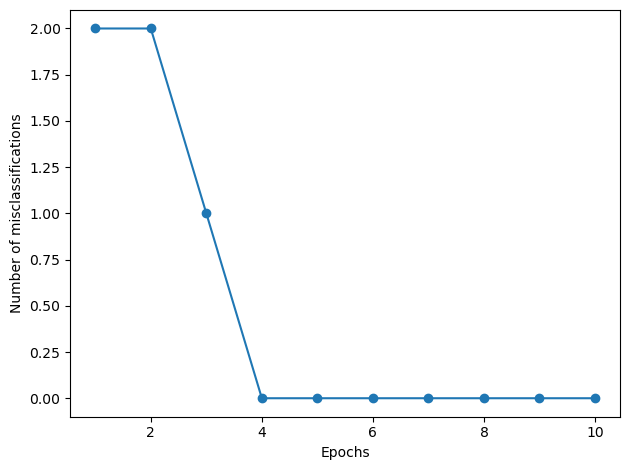

In [229]:
plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker= 'o')
plt.xlabel('Epochs')
plt.ylabel('Number of misclassifications')

plt.tight_layout()
plt.savefig('perceptron_2OR.png', dpi=300)
plt.show()

### 8) TO DO: Complete the tables below in your notebook

You should:
1. Modify your code by modifying the weights so that they start with the values in the table below
2. Also, modify the learning rate η so that it is consistent with the row. Recall η is between 0.0 and 1.0.

Complete the table below for several runs of your model in your notebook (NOTE: Just change the weights and learning rate in
your code, run it and record the output values in the table below. Under no circumstance are you to duplicate the python
perceptron class code in the notebooks 4 or 5 times!


<table style = width = "200%", border = 1>
    <tr>
        <th>Run#</th>
        <th> n </th>
        <th> Epochs to convergence </th>
        <th> w0(inital) </th>
        <th> w1(inital) </th>
        <th> w2(initial)</th>
        <th> w0(Final) </th>
        <th> w1(Final) </th>
        <th> w2(Final) </th>
    </tr>
    <tr>
        <td> 1 (AND) </td>
        <td> 0.1 </td>
        <td> <center> 4</center> </td>
        <td> 0.5 </td>
        <td> 0.5 </td>
        <td> 0.5 </td>
        <td> -0.3 </td>
        <td> 0.2 </td>
        <td> 0.2</td>
    </tr>
    <tr>
        <td> 2 (AND)</td>
        <td> 0.4 </td>
        <td><center>9</center> </td>
        <td> .7 </td>
        <td> .-2 </td>
        <td> .6 </td>
        <td> -1.3 </td>
        <td> 0.6 </td>
        <td> 1 </td>
    </tr>
    <tr>
        <td> 3 (OR) </td>
        <td> 0.1 </td>
        <td> <center> 5 </center> </td>
        <td> 0.1 </td>
        <td> -0.1 </td>
        <td> 0.2 </td>
        <td> -0.1 </td>
        <td> 0.1 </td>
        <td> 0.2 </td>
    </tr>
    <tr>
        <td> 4 (OR) </td>
        <td> 0.6 </td>
        <td> <center>5</center> </td>
        <td> 0.1 </td>
        <td> 0.1 </td>
        <td> -0.3 </td>
        <td> -0.5</td>
        <td> 0.7</td>
        <td> 0.9</td>
    </tr>
</table>

### 9) TO DO: Performance on "unseen" data (do this for the AND Gate only)

To ensure consistent answers, use these parameters BEFORE you start this section::
1. All weights equal to 0.5
2. Use the default values for the learning rate (0.1) and the number of epochs (10)
3. Use the AND gate dataset, i.e. re-train your model with these parameters ans the AND gate datset Test the classifier’s predict method on the input instance X_new=np.array([[1, 1]]) . Make sure your, in your print statement, that you compare the prediction to the expected result.

In [153]:
X_new = np.array([[1,1]])
print('X_new.shape is: {}'.format(X_new.shape))

X_new.shape is: (1, 2)


In [154]:
ppn.fit(X_new, y)
ppn.predict(X_new)

array([0])

It does not predict the outcome correctly.